In [2]:
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [3]:
df = pd.read_csv("healthcare_dataset_with_los.csv")

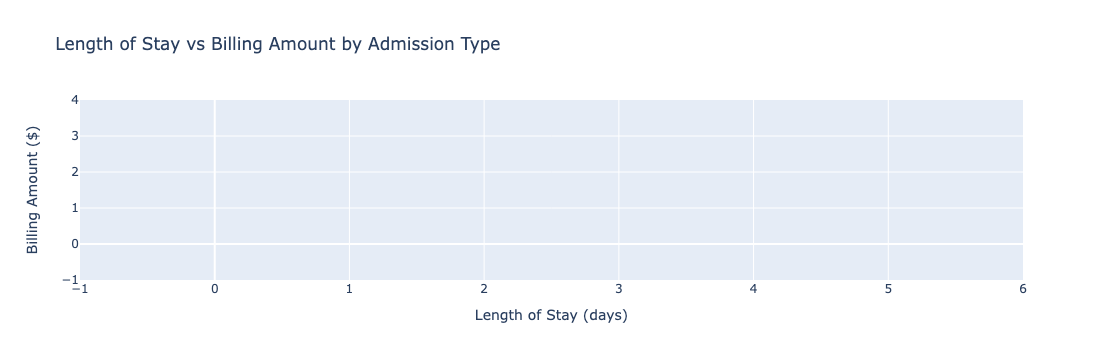

In [4]:
fig = px.scatter(
    df,
    x="Length of Stay",
    y="Billing Amount",
    color="Admission Type",
    title="Length of Stay vs Billing Amount by Admission Type",
    labels={
        "Length of Stay": "Length of Stay (days)",
        "Billing Amount": "Billing Amount ($)",
    },
)
fig.show()

In [5]:
from statsmodels.multivariate.manova import MANOVA

alpha = 0.05

# Fit MANOVA model using statsmodels
maov = MANOVA.from_formula(
    'Q("Billing Amount") + Q("Length of Stay") ~ Q("Admission Type")', data=df
)
result = maov.mv_test()
print(result.summary())

# Extract Wilks' Lambda F-statistic and p-value for Admission Type
stat_table = result.results['Q("Admission Type")']["stat"]
wilks_row = stat_table.loc["Wilks' lambda"]
manova_stat = wilks_row["F Value"]
p_value = wilks_row["Pr > F"]

print(f"\nWilks' Lambda F-statistic: {manova_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Alpha: {alpha}")
print()
if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print(
        "There IS a significant difference either in billing amounts, Length of stay or both between different admission types."
    )
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print(
        "There is NO significant difference in billing amounts, Length of stay between the different admission types."
    )

                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.3141 2.0000 55496.0000 60592.3356 0.0000
         Pillai's trace 0.6859 2.0000 55496.0000 60592.3356 0.0000
 Hotelling-Lawley trace 2.1837 2.0000 55496.0000 60592.3356 0.0000
    Roy's greatest root 2.1837 2.0000 55496.0000 60592.3356 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
    Q("Admission Type")   Value  Num DF    Den DF   F Value Pr > F
------------------------------------------------------------------
            Wilks' lambda 0.9999 4.0000 110992.0000  1.2415 0.2908
           Pilla

## Assumption Checks

### 1. Normality Test (Shapiro-Wilk)
Test whether **Billing Amount** and **Length of Stay** are normally distributed within each Admission Type group.

### 2. Homogeneity of Variances (Levene's Test)
Test whether the variances across Admission Type groups are equal for each dependent variable.

In [6]:
from scipy.stats import shapiro, levene

dep_vars = ["Billing Amount", "Length of Stay"]
groups = df["Admission Type"].unique()

alpha = 0.05

# ── 1. Shapiro-Wilk Normality Test ───────────────────────────────────────────
print("=" * 60)
print("SHAPIRO-WILK NORMALITY TEST")
print("=" * 60)
for var in dep_vars:
    print(f"\nVariable: {var}")
    print(f"{'Group':<20} {'W-stat':>10} {'p-value':>10} {'Normal?':>10}")
    print("-" * 55)
    for group in sorted(groups):
        subset = df.loc[df["Admission Type"] == group, var].dropna()
        stat, p = shapiro(subset)
        normal = "Yes" if p >= alpha else "No"
        print(f"{group:<20} {stat:>10.4f} {p:>10.4f} {normal:>10}")

# ── 2. Levene's Test for Equality of Variances ───────────────────────────────
print("\n" + "=" * 60)
print("LEVENE'S TEST FOR EQUALITY OF VARIANCES")
print("=" * 60)
print(f"\n{'Variable':<25} {'F-stat':>10} {'p-value':>10} {'Equal Var?':>12}")
print("-" * 60)
for var in dep_vars:
    group_data = [
        df.loc[df["Admission Type"] == g, var].dropna().values for g in sorted(groups)
    ]
    stat, p = levene(*group_data)
    equal = "Yes" if p >= alpha else "No"
    print(f"{var:<25} {stat:>10.4f} {p:>10.4f} {equal:>12}")

print("\nAlpha:", alpha)

SHAPIRO-WILK NORMALITY TEST

Variable: Billing Amount
Group                    W-stat    p-value    Normal?
-------------------------------------------------------
Elective                 0.9574     0.0000         No
Emergency                0.9574     0.0000         No
Urgent                   0.9566     0.0000         No

Variable: Length of Stay
Group                    W-stat    p-value    Normal?
-------------------------------------------------------
Elective                 0.9529     0.0000         No
Emergency                0.9513     0.0000         No
Urgent                   0.9519     0.0000         No

LEVENE'S TEST FOR EQUALITY OF VARIANCES

Variable                      F-stat    p-value   Equal Var?
------------------------------------------------------------
Billing Amount                0.7118     0.4908          Yes
Length of Stay                0.7048     0.4942          Yes

Alpha: 0.05


/opt/miniconda3/envs/my_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18655.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/my_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18269.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/my_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18576.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/my_env/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 18655.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/my_env/

## Kruskal-Wallis H-Test

A non-parametric alternative to one-way ANOVA. Applied separately for each dependent variable (**Billing Amount** and **Length of Stay**) across the three **Admission Type** groups.

- **H₀**: The distribution of the dependent variable is the same across all Admission Type groups.  
- **H₁**: At least one group has a different distribution.

In [7]:
from scipy.stats import kruskal

alpha = 0.05
dep_vars = ["Billing Amount", "Length of Stay"]

print("=" * 60)
print("KRUSKAL-WALLIS H-TEST")
print("=" * 60)

for var in dep_vars:
    print(f"\nDependent Variable: {var}")
    print(f"H₀: Distribution of '{var}' is equal across all Admission Type groups.")
    print(f"H₁: At least one Admission Type group has a different distribution.\n")

    group_data = [
        df.loc[df["Admission Type"] == g, var].dropna().values
        for g in sorted(df["Admission Type"].unique())
    ]

    h_stat, p_value = kruskal(*group_data)

    print(f"  H-statistic : {h_stat:.4f}")
    print(f"  P-value     : {p_value:.4f}")
    print(f"  Alpha       : {alpha}")

    if p_value < alpha:
        print(f"  Result      : Reject the Null Hypothesis.")
        print(
            f"  There IS a significant difference in '{var}' across Admission Type groups."
        )
    else:
        print(f"  Result      : Fail to Reject the Null Hypothesis.")
        print(
            f"  There is NO significant difference in '{var}' across Admission Type groups."
        )
    print("-" * 60)

KRUSKAL-WALLIS H-TEST

Dependent Variable: Billing Amount
H₀: Distribution of 'Billing Amount' is equal across all Admission Type groups.
H₁: At least one Admission Type group has a different distribution.

  H-statistic : 0.5829
  P-value     : 0.7472
  Alpha       : 0.05
  Result      : Fail to Reject the Null Hypothesis.
  There is NO significant difference in 'Billing Amount' across Admission Type groups.
------------------------------------------------------------

Dependent Variable: Length of Stay
H₀: Distribution of 'Length of Stay' is equal across all Admission Type groups.
H₁: At least one Admission Type group has a different distribution.

  H-statistic : 4.4218
  P-value     : 0.1096
  Alpha       : 0.05
  Result      : Fail to Reject the Null Hypothesis.
  There is NO significant difference in 'Length of Stay' across Admission Type groups.
------------------------------------------------------------


## PERMANOVA (Permutational Multivariate Analysis of Variance)

A non-parametric multivariate method that tests whether group centroids differ in multivariate space using permutations — no normality assumption required.

- **H₀**: The multivariate distribution of **Billing Amount** and **Length of Stay** is the same across all Admission Type groups.  
- **H₁**: At least one group has a different multivariate distribution.

Uses **Euclidean distance** on standardized features with **999 permutations**.

In [4]:
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

alpha = 0.05
n_permutations = 999

# ── Prepare data ─────────────────────────────────────────────────────────────
features = df[["Billing Amount", "Length of Stay"]].dropna()
labels = df.loc[features.index, "Admission Type"].values

# Standardize so both variables contribute equally
scaler = StandardScaler()
X = scaler.fit_transform(features.values)

# 🌟 THE FIX: Calculate the distance matrix ONCE right here! 🌟
print("Calculating distance matrix (this may take a moment)...")
dist_matrix = cdist(X, X, metric="euclidean")


# ── Compute pseudo-F statistic ────────────────────────────────────────────────
def permanova_pseudo_f(dist_matrix, labels):
    """Compute the PERMANOVA pseudo-F statistic using a pre-calculated distance matrix."""
    groups = np.unique(labels)
    n = len(labels)

    # Total sum of squares
    ss_total = (dist_matrix**2).sum() / (2 * n)

    # Within-group sum of squares
    ss_within = 0.0
    for g in groups:
        idx = np.where(labels == g)[0]
        n_g = len(idx)
        ss_within += (dist_matrix[np.ix_(idx, idx)] ** 2).sum() / (2 * n_g)

    ss_between = ss_total - ss_within
    k = len(groups)

    pseudo_f = (ss_between / (k - 1)) / (ss_within / (n - k))
    return pseudo_f


# Observed pseudo-F
observed_f = permanova_pseudo_f(dist_matrix, labels)

# Permutation test
print("Running permutations...")
perm_f_values = []
for _ in range(n_permutations):
    permuted_labels = np.random.permutation(labels)
    # Pass the pre-calculated matrix into the function
    perm_f_values.append(permanova_pseudo_f(dist_matrix, permuted_labels))

perm_f_values = np.array(perm_f_values)
p_value = (np.sum(perm_f_values >= observed_f) + 1) / (n_permutations + 1)

# ── Results ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PERMANOVA RESULTS")
print("=" * 60)
print(f"  Dependent Variables : Billing Amount, Length of Stay")
print(f"  Grouping Variable   : Admission Type")
print(f"  Distance Metric     : Euclidean (standardized)")
print(f"  Permutations        : {n_permutations}")
print(f"\n  Pseudo-F statistic  : {observed_f:.4f}")
print(f"  P-value             : {p_value:.4f}")
print(f"  Alpha               : {alpha}")
print()
if p_value < alpha:
    print("  Result: Reject the Null Hypothesis.")
    print("  There IS a significant multivariate difference in Billing Amount")
    print("  and Length of Stay across Admission Type groups.")
else:
    print("  Result: Fail to Reject the Null Hypothesis.")
    print("  There is NO significant multivariate difference in Billing Amount")
    print("  and Length of Stay across Admission Type groups.")
print("=" * 60)

Calculating distance matrix (this may take a moment)...


: 

In [4]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

# Set our random seed so your results match mine
np.random.seed(42)
alpha = 0.05
n_permutations = 999

# ── 1. The Cake Analogy: Take a representative sample ────────────────────────
# We take 2000 rows to completely avoid the RAM crash
sampled_df = df.sample(n=2000, random_state=42)

# ── 2. Prepare data using ONLY the sample ────────────────────────────────────
features = sampled_df[["Billing Amount", "Length of Stay"]].dropna()
labels = sampled_df.loc[features.index, "Admission Type"].values

# Standardize so both variables contribute equally
scaler = StandardScaler()
X = scaler.fit_transform(features.values)

# ── 3. Calculate the distance matrix ONCE ────────────────────────────────────
print("Calculating distance matrix for the 2,000 patient sample...")
dist_matrix = cdist(X, X, metric="euclidean")


# ── 4. Compute pseudo-F statistic function ───────────────────────────────────
def permanova_pseudo_f(dist_matrix, labels):
    """Compute the PERMANOVA pseudo-F statistic using a pre-calculated distance matrix."""
    groups = np.unique(labels)
    n = len(labels)

    # Total sum of squares
    ss_total = (dist_matrix**2).sum() / (2 * n)

    # Within-group sum of squares
    ss_within = 0.0
    for g in groups:
        idx = np.where(labels == g)[0]
        n_g = len(idx)
        ss_within += (dist_matrix[np.ix_(idx, idx)] ** 2).sum() / (2 * n_g)

    ss_between = ss_total - ss_within
    k = len(groups)

    pseudo_f = (ss_between / (k - 1)) / (ss_within / (n - k))
    return pseudo_f


# ── 5. Run the Permutation Test ──────────────────────────────────────────────
# Observed pseudo-F
observed_f = permanova_pseudo_f(dist_matrix, labels)

# Permutation test
print("Running permutations...")
perm_f_values = []
for _ in range(n_permutations):
    permuted_labels = np.random.permutation(labels)
    perm_f_values.append(permanova_pseudo_f(dist_matrix, permuted_labels))

perm_f_values = np.array(perm_f_values)
p_value = (np.sum(perm_f_values >= observed_f) + 1) / (n_permutations + 1)

# ── 6. Results ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PERMANOVA RESULTS")
print("=" * 60)
print(f"  Pseudo-F statistic  : {observed_f:.4f}")
print(f"  P-value             : {p_value:.4f}")
print(f"  Alpha               : {alpha}")
print()
if p_value < alpha:
    print("  Result: Reject the Null Hypothesis.")
else:
    print("  Result: Fail to Reject the Null Hypothesis.")
print("=" * 60)

Calculating distance matrix for the 2,000 patient sample...
Running permutations...

PERMANOVA RESULTS
  Pseudo-F statistic  : 1.6217
  P-value             : 0.1670
  Alpha               : 0.05

  Result: Fail to Reject the Null Hypothesis.
